# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

### Carregamento, criação dataset e do dataloader

In [3]:
dataset_dir = 'MNIST/'

# Load the full MNIST training dataset
full_train_dataset = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

# Define the split ratio (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split the dataset
dataset_train, dataset_val = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create DataLoaders for training and validation
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False) # No need to shuffle validation data

print(f'Número total de amostras de treinamento original: {len(full_train_dataset)}')
print(f'Número de amostras de treinamento: {len(dataset_train)}')
print(f'Número de amostras de validação: {len(dataset_val)}')
print('Número de minibatches de treinamento:', len(loader_train))
print('Número de minibatches de validação:', len(loader_val))

x_train_sample, y_train_sample = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch de treinamento:", x_train_sample.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train_sample), torch.max(x_train_sample))
print("Tipo dos dados das imagens:         ", type(x_train_sample))
print("Tipo das classes das imagens:       ", type(y_train_sample))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


Número total de amostras de treinamento original: 60000
Número de amostras de treinamento: 48000
Número de amostras de validação: 12000
Número de minibatches de treinamento: 480
Número de minibatches de validação: 120

Dimensões dos dados de um minibatch de treinamento: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


### Usando todas as amostras do MNIST

Neste exemplo utilizaremos todas as amostras de treinamento.

In [4]:
# The original `total_samples` was for the full training set. Now we have a split.
n_batches_train = len(loader_train)
n_batches_val = len(loader_val)
total_train_samples = len(dataset_train)
total_val_samples = len(dataset_val)

print(f'Número de minibatches de treinamento: {n_batches_train}')
print(f'Número de minibatches de validação: {n_batches_val}')
print(f'Total de amostras de treinamento: {total_train_samples}')
print(f'Total de amostras de validação: {total_val_samples}')

Número de minibatches de treinamento: 480
Número de minibatches de validação: 120
Total de amostras de treinamento: 48000
Total de amostras de validação: 12000


## Modelo

In [5]:
model = torch.nn.Linear(28*28, 10)

In [6]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[-0.6800,  0.1145,  0.0802, -0.4926,  0.3528,  1.2105, -0.4520,  0.9691,
         -0.6915,  0.2549]], grad_fn=<AddmmBackward0>)

In [7]:
model(dataset_train[0][0].view(-1, 784))

tensor([[-0.3555,  0.3119, -0.1547,  0.1130,  0.1515,  0.2280,  0.0892,  0.0457,
         -0.0681,  0.0542]], grad_fn=<AddmmBackward0>)

## Treinamento

Durante o treinamento, acompanharemos a perda e a acurácia para os conjuntos de treinamento e validação em cada época.

### Inicialização dos parâmetros

In [8]:
n_epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [9]:
train_losses_per_epoch = []
val_losses_per_epoch = []
train_accuracies_per_epoch = []
val_accuracies_per_epoch = []

for epoch in range(n_epochs):
    # Training phase
    model.train() # Set model to training mode
    correct_train = 0
    total_train = 0
    running_train_loss = 0.0

    for i, (x_train, y_train) in enumerate(loader_train):
        inputs = x_train.view(-1, 28 * 28)
        labels = y_train

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(loader_train)
    train_accuracy = correct_train / total_train
    train_losses_per_epoch.append(avg_train_loss)
    train_accuracies_per_epoch.append(train_accuracy)

    # Validation phase
    model.eval() # Set model to evaluation mode
    correct_val = 0
    total_val = 0
    running_val_loss = 0.0

    with torch.no_grad(): # Disable gradient calculations during validation
        for x_val, y_val in loader_val:
            inputs_val = x_val.view(-1, 28 * 28)
            labels_val = y_val

            outputs_val = model(inputs_val)
            loss_val = criterion(outputs_val, labels_val)

            running_val_loss += loss_val.item()
            _, predicted_val = torch.max(outputs_val.data, 1)
            total_val += labels_val.size(0)
            correct_val += (predicted_val == labels_val).sum().item()

    avg_val_loss = running_val_loss / len(loader_val)
    val_accuracy = correct_val / total_val
    val_losses_per_epoch.append(avg_val_loss)
    val_accuracies_per_epoch.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{n_epochs}], ' \
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, ' \
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

Epoch [1/10], Train Loss: 0.4097, Train Acc: 0.8841, Val Loss: 0.3225, Val Acc: 0.9069
Epoch [2/10], Train Loss: 0.3149, Train Acc: 0.9111, Val Loss: 0.3050, Val Acc: 0.9127
Epoch [3/10], Train Loss: 0.2989, Train Acc: 0.9161, Val Loss: 0.2891, Val Acc: 0.9179
Epoch [4/10], Train Loss: 0.2896, Train Acc: 0.9192, Val Loss: 0.2849, Val Acc: 0.9183
Epoch [5/10], Train Loss: 0.2846, Train Acc: 0.9199, Val Loss: 0.2789, Val Acc: 0.9221
Epoch [6/10], Train Loss: 0.2799, Train Acc: 0.9214, Val Loss: 0.2839, Val Acc: 0.9199
Epoch [7/10], Train Loss: 0.2768, Train Acc: 0.9223, Val Loss: 0.2763, Val Acc: 0.9224
Epoch [8/10], Train Loss: 0.2730, Train Acc: 0.9234, Val Loss: 0.2767, Val Acc: 0.9230
Epoch [9/10], Train Loss: 0.2715, Train Acc: 0.9246, Val Loss: 0.2756, Val Acc: 0.9237
Epoch [10/10], Train Loss: 0.2690, Train Acc: 0.9246, Val Loss: 0.2764, Val Acc: 0.9225


In [10]:
print('--- Treinamento Finalizado ---')
print(f'Última perda de treinamento: {train_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de treinamento: {train_accuracies_per_epoch[-1]:.4f}')
print(f'Última perda de validação: {val_losses_per_epoch[-1]:.4f}')
print(f'Última acurácia de validação: {val_accuracies_per_epoch[-1]:.4f}')

--- Treinamento Finalizado ---
Última perda de treinamento: 0.2690
Última acurácia de treinamento: 0.9246
Última perda de validação: 0.2764
Última acurácia de validação: 0.9225


### Visualizando a evolução da perda e acurácia

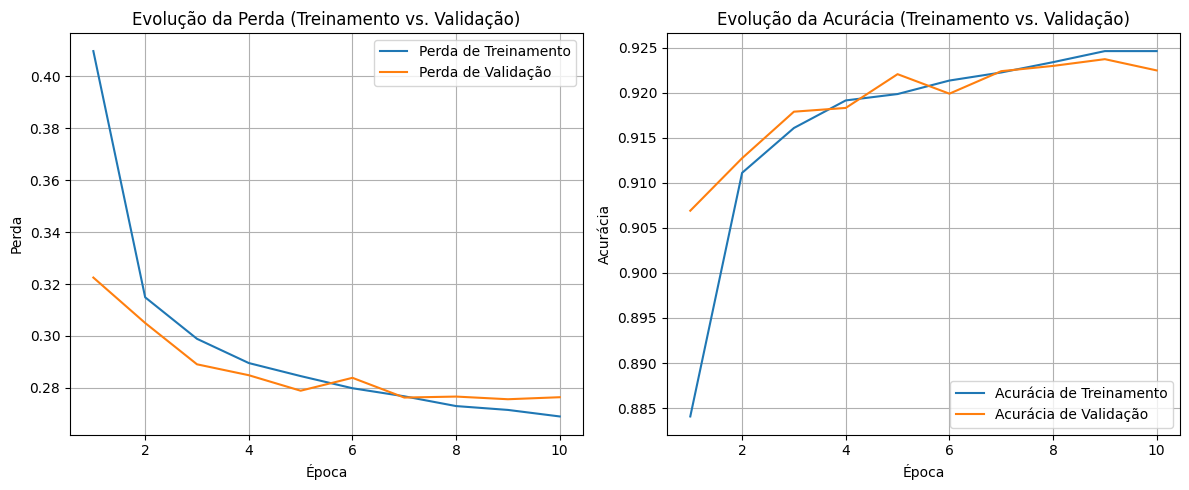

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs + 1), train_losses_per_epoch, label='Perda de Treinamento')
plt.plot(range(1, n_epochs + 1), val_losses_per_epoch, label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Evolução da Perda (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs + 1), train_accuracies_per_epoch, label='Acurácia de Treinamento')
plt.plot(range(1, n_epochs + 1), val_accuracies_per_epoch, label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Evolução da Acurácia (Treinamento vs. Validação)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observações sobre os gráficos

Estes gráficos mostram a perda e a acurácia calculadas ao final de cada época para os conjuntos de treinamento e validação. Idealmente, a perda de treinamento e validação deve diminuir, e a acurácia deve aumentar, com as curvas de validação seguindo de perto as de treinamento. Divergências significativas podem indicar overfitting ou underfitting.

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?

R.: batch_size = 100

2. Em uma época, quantos mini-batches existem?

R.: 42000 valores de X_train. 42000/100 = 420 mini-batches

3. Qual é a definição de época?

R.: Quando o modelo calcula e ajusta os pesos baseado em todos os elementos do dataset (em todos os mini-batches)


## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 600
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

In [12]:
for epoch in range(n_epochs):

    model.train()
    running_train_loss = 0

    for i, (x_train, y_train) in enumerate(loader_train, start=1):

        inputs = x_train.view(-1, 28 * 28)

        outputs = model(inputs)

        loss = criterion(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # PRINT DE CADA MINIBATCH
        print(
            f'Época: {epoch+1}/{n_epochs}, '
            f'batch: {i}/{len(loader_train)}'
        )

    avg_train_loss = running_train_loss / len(loader_train)

    print(
        f'Fim da época {epoch+1}/{n_epochs} | '
        f'Perda Treino: {avg_train_loss:.4f}'
    )

Época: 1/10, batch: 1/480
Época: 1/10, batch: 2/480
Época: 1/10, batch: 3/480
Época: 1/10, batch: 4/480
Época: 1/10, batch: 5/480
Época: 1/10, batch: 6/480
Época: 1/10, batch: 7/480
Época: 1/10, batch: 8/480
Época: 1/10, batch: 9/480
Época: 1/10, batch: 10/480
Época: 1/10, batch: 11/480
Época: 1/10, batch: 12/480
Época: 1/10, batch: 13/480
Época: 1/10, batch: 14/480
Época: 1/10, batch: 15/480
Época: 1/10, batch: 16/480
Época: 1/10, batch: 17/480
Época: 1/10, batch: 18/480
Época: 1/10, batch: 19/480
Época: 1/10, batch: 20/480
Época: 1/10, batch: 21/480
Época: 1/10, batch: 22/480
Época: 1/10, batch: 23/480
Época: 1/10, batch: 24/480
Época: 1/10, batch: 25/480
Época: 1/10, batch: 26/480
Época: 1/10, batch: 27/480
Época: 1/10, batch: 28/480
Época: 1/10, batch: 29/480
Época: 1/10, batch: 30/480
Época: 1/10, batch: 31/480
Época: 1/10, batch: 32/480
Época: 1/10, batch: 33/480
Época: 1/10, batch: 34/480
Época: 1/10, batch: 35/480
Época: 1/10, batch: 36/480
Época: 1/10, batch: 37/480
Época: 1/1

In [13]:
batch_sizes = [32, 100, 512]

all_losses = {}

for batch_size in batch_sizes:

    print(f'\nTreinando com batch_size = {batch_size}')

    loader_train = DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=True
    )

    model = torch.nn.Linear(28*28, 10)

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learningRate
    )

    train_losses = []

    for epoch in range(n_epochs):

        model.train()

        running_loss = 0

        for i, (x_train, y_train) in enumerate(loader_train, start=1):

            inputs = x_train.view(-1, 28 * 28)

            outputs = model(inputs)

            loss = criterion(outputs, y_train)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            print(
                f'Época: {epoch+1}/{n_epochs}, '
                f'batch: {i}/{len(loader_train)}'
            )

        avg_loss = running_loss / len(loader_train)

        train_losses.append(avg_loss)

        print(
            f'Fim da época {epoch+1}/{n_epochs} | '
            f'Perda: {avg_loss:.4f}'
        )

    all_losses[f'Batch {batch_size}'] = train_losses

A saída de streaming foi truncada nas últimas 5000 linhas.
Época: 2/10, batch: 282/480
Época: 2/10, batch: 283/480
Época: 2/10, batch: 284/480
Época: 2/10, batch: 285/480
Época: 2/10, batch: 286/480
Época: 2/10, batch: 287/480
Época: 2/10, batch: 288/480
Época: 2/10, batch: 289/480
Época: 2/10, batch: 290/480
Época: 2/10, batch: 291/480
Época: 2/10, batch: 292/480
Época: 2/10, batch: 293/480
Época: 2/10, batch: 294/480
Época: 2/10, batch: 295/480
Época: 2/10, batch: 296/480
Época: 2/10, batch: 297/480
Época: 2/10, batch: 298/480
Época: 2/10, batch: 299/480
Época: 2/10, batch: 300/480
Época: 2/10, batch: 301/480
Época: 2/10, batch: 302/480
Época: 2/10, batch: 303/480
Época: 2/10, batch: 304/480
Época: 2/10, batch: 305/480
Época: 2/10, batch: 306/480
Época: 2/10, batch: 307/480
Época: 2/10, batch: 308/480
Época: 2/10, batch: 309/480
Época: 2/10, batch: 310/480
Época: 2/10, batch: 311/480
Época: 2/10, batch: 312/480
Época: 2/10, batch: 313/480
Época: 2/10, batch: 314/480
Época: 2/10, batc

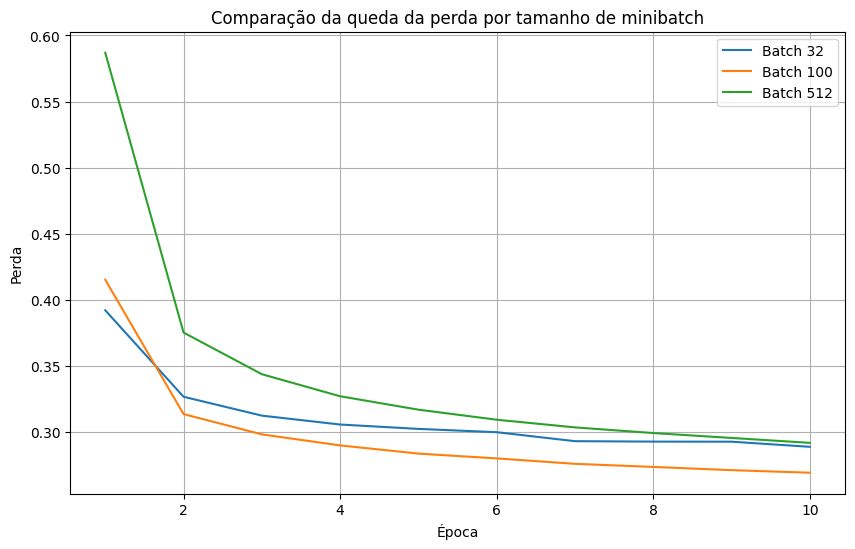

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for label, losses in all_losses.items():

    plt.plot(
        range(1, n_epochs+1),
        losses,
        label=label
    )

plt.xlabel("Época")
plt.ylabel("Perda")
plt.title("Comparação da queda da perda por tamanho de minibatch")

plt.legend()

plt.grid()

plt.show()

## Conclusões sobre os experimentos deste notebook


Os experimentos mostraram que o tamanho do minibatch influencia diretamente o comportamento do treinamento. Batchs menores apresentaram maior frequência de atualização e convergência mais rápida, porém com mais oscilações na perda. Já batchs maiores geraram curvas mais estáveis, mas com redução da perda mais gradual. O tamanho intermediário apresentou um equilíbrio entre estabilidade e velocidade de aprendizado.